## Calculating displacement due to faulting

This notebook will calculate _displacement_ at specified points due to _slip_ on a fault. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np # Numerical analysis
import meshio # Interaction between fault model files and Python
import matplotlib.pyplot as plt # Visualize 
from pyproj import Proj
import pyproj
import h5py
import cutde.halfspace as cutde

%matplotlib widget

### Define some basic coordinate transformation functions

These functions convert between spherical and geocentric Cartesian coordinates.

In [2]:
# Define some basic coordinate transformation functions
GEOID = pyproj.Geod(ellps="WGS84") # Define the geoid
KM2M = 1.0e3 # Conversion factor, km to m
RADIUS_EARTH = np.float64((GEOID.a + GEOID.b) / 2) # Average radius of Earth

# Convert spherical to geocentric Cartesian coordinates
def sph2cart(lon, lat, radius):
    lon_rad = np.deg2rad(lon)
    lat_rad = np.deg2rad(lat)
    x = radius * np.cos(lat_rad) * np.cos(lon_rad)
    y = radius * np.cos(lat_rad) * np.sin(lon_rad)
    z = radius * np.sin(lat_rad)
    return x, y, z

# Convert geocentric Cartesian to spherical coordinates
def cart2sph(x, y, z):
    azimuth = np.arctan2(y, x)
    elevation = np.arctan2(z, np.sqrt(x ** 2 + y ** 2))
    r = np.sqrt(x ** 2 + y ** 2 + z ** 2)
    return azimuth, elevation, r

# Convert negative longitudes to 0–360º convention 
def wrap2360(lon):
    lon[np.where(lon < 0.0)] += 360.0
    return lon

### Read fault geometry file and parse triangular elements

The fault geometry is defined using triangular dislocation elements (TDEs), which allow for approximation of geometrically complex surfaces. 

The nodes of the mesh are defined as 3-dimensional _x_, _y_, _z_ coordinates and can be specified for geographic meshes as _longitude (º)_, _latitude (º)_, _depth (km)_. These nodes are stored as the m-by-3 field `points` of the `mesh` dictionary:

```
mesh["points"] = np.array([[1, 1, 0], [0.5, 0, 0], [0, 1, 0]])
```

The nodes are connected to form elements, with the entries of rows of the n-by-3 field `verts` of the `mesh` dictionary specifying the row indices of `mesh["points"]` that are connected to circulate the element in a counterclockwise manner. This circulation allows the normal vector (cross product of the TDE legs) to point upward for a dipping element. 

```
mesh["verts"] = np.array([0, 2, 1])
```

In the drawing below, element 0 is defined by nodes 0, 2, and 1, and the nodal coordinates are as specified above. 


```
2 ------- 0
 \       / 
  \  0  /  
   \   /   
    \ /    
     1     
```

In [3]:
# Read in source fault
filename = "cascadia.msh"
mesh = dict()
meshobj = meshio.read(filename)
mesh["file_name"] = filename
# The points field contains longitude, latitude, depth coordinates of the nodes of the triangles (m-by-3)
mesh["points"] = meshobj.points
# The verts field is a set of row indices into the points field, indicating which nodes comprise each triangle (n-by-3)
mesh["verts"] = meshio.CellBlock("triangle", meshobj.get_cells_type("triangle")).data
# Count of triangular elements
ntri = len(mesh["verts"])

# Expand mesh coordinates
mesh["lon1"] = mesh["points"][mesh["verts"][:, 0], 0]
mesh["lon2"] = mesh["points"][mesh["verts"][:, 1], 0]
mesh["lon3"] = mesh["points"][mesh["verts"][:, 2], 0]
mesh["lat1"] = mesh["points"][mesh["verts"][:, 0], 1]
mesh["lat2"] = mesh["points"][mesh["verts"][:, 1], 1]
mesh["lat3"] = mesh["points"][mesh["verts"][:, 2], 1]
mesh["dep1"] = mesh["points"][mesh["verts"][:, 0], 2]
mesh["dep2"] = mesh["points"][mesh["verts"][:, 1], 2]
mesh["dep3"] = mesh["points"][mesh["verts"][:, 2], 2]
# Calculate centroids
mesh["centroids"] = np.mean(mesh["points"][mesh["verts"], :], axis=1)

# Convert nodes to Cartesian coordinates in meters
mesh["x1"], mesh["y1"], mesh["z1"] = sph2cart(
    mesh["lon1"],
    mesh["lat1"],
    RADIUS_EARTH + KM2M * mesh["dep1"],
)
mesh["x2"], mesh["y2"], mesh["z2"] = sph2cart(
    mesh["lon2"],
    mesh["lat2"],
    RADIUS_EARTH + KM2M * mesh["dep2"],
)
mesh["x3"], mesh["y3"], mesh["z3"] = sph2cart(
    mesh["lon3"],
    mesh["lat3"],
    RADIUS_EARTH + KM2M * mesh["dep3"],
)
# Cartesian triangle centroids
mesh["x_centroid"] = (mesh["x1"] + mesh["x2"] + mesh["x3"]) / 3.0
mesh["y_centroid"] = (mesh["y1"] + mesh["y2"] + mesh["y3"]) / 3.0
mesh["z_centroid"] = (mesh["z1"] + mesh["z2"] + mesh["z3"]) / 3.0

# Calculate cross products, which give element orientations
tri_leg1 = np.transpose([np.deg2rad(mesh["lon2"] - mesh["lon1"]), np.deg2rad(mesh["lat2"] - mesh["lat1"]), (1 + KM2M * mesh["dep2"] / RADIUS_EARTH) - (1 + KM2M * mesh["dep1"] / RADIUS_EARTH)])
tri_leg2 = np.transpose([np.deg2rad(mesh["lon3"] - mesh["lon1"]), np.deg2rad(mesh["lat3"] - mesh["lat1"]), (1 + KM2M * mesh["dep3"] / RADIUS_EARTH) - (1 + KM2M * mesh["dep1"] / RADIUS_EARTH)])
# Normal vector for each element
mesh["nv"] = np.cross(tri_leg1, tri_leg2)
# Convert Cartesian normal vector to angular units
azimuth, elevation, r = cart2sph(mesh["nv"][:, 0], mesh["nv"][:, 1], mesh["nv"][:, 2])
# Extract geometric quantities for each element
mesh["strike"] = wrap2360(-np.rad2deg(azimuth))
mesh["dip"] = 90 - np.rad2deg(elevation)
mesh["dip_flag"] = mesh["dip"] != 90

### Read GNSS data

In [23]:
gnss = pd.read_csv('casc_sse_07-2011.csv')
nsta = len(gnss)

lon_corr = 1
# Check longitude convention of mesh
# If longitudes are already 0–360º, we don't need to convert
if np.max(gnss.lon) > 180:
    lon_corr = 0

# Reshape grid into a 3 column array
pts = np.array([gnss.lon, gnss.lat, 0 * gnss.lat]).reshape((3, -1)).T.copy()

### Plot fault and stations

In [ ]:
# Setting up axis limits around fault
lonmin = np.mean(mesh["points"][:, 0]) - 3*np.std(mesh["points"][:, 0])
lonmax = np.mean(mesh["points"][:, 0]) + 3*np.std(mesh["points"][:, 0])
latmin = np.mean(mesh["points"][:, 1]) - 3*np.std(mesh["points"][:, 1])
latmax = np.mean(mesh["points"][:, 1]) + 3*np.std(mesh["points"][:, 1])

# Read in coastline file
coast = pd.read_csv("coastline.csv")
# Define the figure and its axis
fig, ax = plt.subplots()
# Draw the fault
ax.triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5)
# Add grid points
ax.plot(pts[:, 0], pts[:, 1], '.r')
# Add coastline
ax.plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax.set(xlim=(lonmin, lonmax), ylim=(latmin, latmax), aspect='equal')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

### Coordinate transformation

Calculating the relationship between fault slip and displacement is done in Cartesian coordinates, so we'll need to convert our longitude, latitude coordinates for both the fault and the GNSS stations. The approach below uses a UTM projection, which is generally a good choice for regions that are aligned in a north-south direction, such as Cascadia. Other map projections would work, too. 

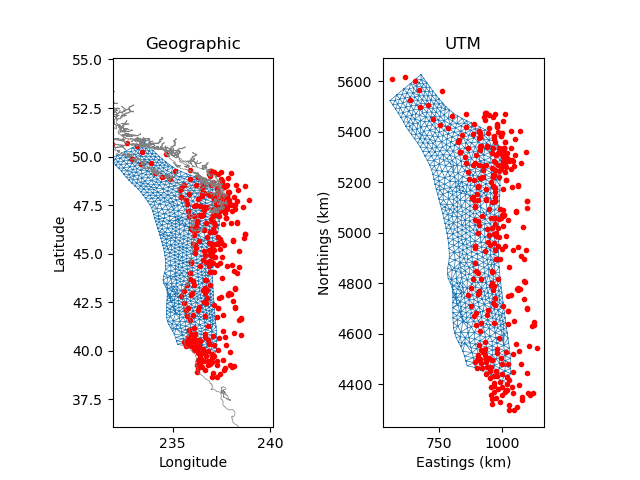

In [5]:
# Convert the fault and station coordinates to UTM coordinates

# Find UTM zone. UTM zones are 6º wide, and this formula finds the EPSG code for the zone 
# WGS 84 zones' EPSG codes start at 32600, and we add the zone to that. Add 100 if in the southern hemisphere. 
utmzone=int(32600 + np.floor((-180 + np.mean(gnss.lon))/6))
if np.mean(gnss.lat) < 0:
    utmzone += 100

# Define target UTM coordinate system
target_crs = 'epsg:'+str(utmzone) 
# Define original source geographic coordinate system
source_crs = 'epsg:4326' # Global lat-lon coordinate system
# Define the coordinate transformation using pyproj 
latlon_to_utm = pyproj.Transformer.from_crs(source_crs, target_crs)

# Convert coordinates of the fault and the stations 
# We're just converting the longitude, latitude coordinates of the fault, as the depths are already in linear units 
# Dividing by 1e3 expresses UTM coordinates in km
faultxy = np.array(latlon_to_utm.transform(mesh["points"][:, 1], mesh["points"][:, 0])).T/1e3
gnssxy = np.array(latlon_to_utm.transform(pts[:, 1], pts[:, 0])).T/1e3 

# Place UTM coordinates into 3-column arrays (x, y, z)
# Allocate space for fault coordinates
cart_fault_pts = np.zeros_like(mesh["points"])
# Insert x, y
cart_fault_pts[:, 0:2] = faultxy
# Insert depths as the third column 
cart_fault_pts[:, 2] = mesh["points"][:, 2]
# Allocate space for grid coordinates
cart_gnss_pts = np.zeros_like(pts)
# Insert x, y
cart_gnss_pts[:, 0:2] = gnssxy
# Insert z (all zero, at the surface of the half-space)
cart_gnss_pts[:, 2] = pts[:, 2]

# Make a plot of the fault and stations, both in geographic and UTM coordinates
fig, ax = plt.subplots(1, 2)
# Draw the fault
ax[0].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5)
# Add grid points
ax[0].plot(pts[:, 0], pts[:, 1], '.r')
# Add coastline
ax[0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0].set(xlim=(lonmin, lonmax), ylim=(latmin, latmax), aspect='equal')
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].set_title("Geographic")

ax[1].triplot(cart_fault_pts[:,0], cart_fault_pts[:, 1], mesh["verts"], linewidth=0.5)
ax[1].plot(cart_gnss_pts[:, 0], cart_gnss_pts[:, 1], '.r')
ax[1].set_aspect("equal")
ax[1].set_xlabel("Eastings (km)")
ax[1].set_ylabel("Northings (km)")
ax[1].set_title("UTM")
plt.show()

In [18]:
# Calculate the mathematical relationship between unit fault slip and displacement
# This takes a bit of time, but it only needs to be done once if your fault geometry and observation coordinates don't change

disp_mat = cutde.disp_matrix(obs_pts=cart_gnss_pts, tris=cart_fault_pts[mesh["verts"]], nu=0.25).reshape((-1, 3*ntri))
# Write to HDF5 file
hf = h5py.File("disp_mat.h5", "w")
hf["disp_mat"] = disp_mat
hf.close()

In [7]:
# Read disp_mat from file

hf = h5py.File('disp_mat.h5', 'r')
disp_mat = np.array(hf["disp_mat"])
hf.close()

### Relating a specific fault slip distribution to a surface displacement field

Using the partial deriviates relating unit slip on each element to displacement at the surface observation coordinates, we can now determine the total displacement at GNSS stations that results from a defined slip distribution on the fault. We can do this by integrating the partial derivatives across the domain of the fault, and in practice we do this through matrix multiplication: matrix multiplication of the partial derivatives times the slip vector yields the total displacement arising from the contributions of all elements' slip magnitudes. 

To get a sense for how a given slip distribution impacts the surface displacement field, we can prescribe a slip distribution and then predict the displacement at GNSS stations. We can propose a slip distribution defined by a 2-dimensional Gaussian distribution, smoothly decaying to zero away from a peak value. We define the center of the distribution, the "steepness" of the decay in the x and y directions, and a rotation of the y-axis. These specifications allow us to specify the distribution in a way that may vary the dimensions along the strike and dip directions of the source fault. 

In [8]:
def radgauss(x0, y0, a, x, y, c):
# 
# RADGAUSS calculates a radial Gaussian distribution.
# 
# S = RADGAUSS(X0, Y0, A, X, Y, C) uses the formula:
# 
# S(Xi, Yi) = A exp(-Ri^2/2C^2)
# 
# to calculate the value S at point (Xi,Yi), which is located a distance
# Ri from point (X0,Y0), where the value is A.  C represents a Gaussian 
# curvature parameter: larger values of C produce more abrupt changes in
# value with distance.
# 
# X0, Y0 represent the x,y coordinates of the point of maximum magnitude A.
# X and Y are n x 1 arrays containing the x,y coordinates of all points at
# which the value S should be calculated.  C is a single value that applies
# to the entire calculation.
# 
# If C is a 2-element vector, the pattern will not be radial but elliptical,
# with the first element of C giving the curvature in the X direction and the
# second giving the curvature in Y:
# 
# S(Xi, Yi) = A exp( [ -(Xi-X0)^2 / 2C[0]^2 ] + [ -(Yi-Y0)^2 / 2C[1]^2] )
# 
# If C is a 3-element vector, an elliptical pattern will result, and the
# ellipse will be rotated C[2] degrees from the y-axis, where a positive 
# number gives a clockwise rotation.
    c = np.array(c)
    if np.size(c) == 1:
        r = np.sqrt((x-x0)**2+(y-y0)**2) # calculate distances
        s = a*np.exp(-r**2/(2*c**2)) # calculate Gaussian value
    elif np.size(c) == 2:
        s = a*np.exp((-(x-x0)**2./(2*c[0]**2)) + (-(y-y0)**2./(2*c[1]**2)))
    elif np.size(c) == 3:
        ang = np.deg2rad(c[2])
        rot = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
        coords = np.vstack((np.hstack((x.T, x0)), np.hstack((y.T, y0))))
        rcoords = rot.dot(coords)
        s = a*np.exp((-(rcoords[0, :-1]-rcoords[0, -1])**2/(2*c[0]**2)) + (-(rcoords[1, :-1]-rcoords[1, -1])**2/(2*c[1]**2)))

    return s  

### Specify slip distribution and predict displacements

This code block can be run repeatedly to generate a trial-and-error prediction of the observed GNSS displacement field. The parameters of the radial Gaussian slip distribution can be edited in the opening lines, and then the rest of the block will calculate the predicted displacement arising from that specified distribution. 

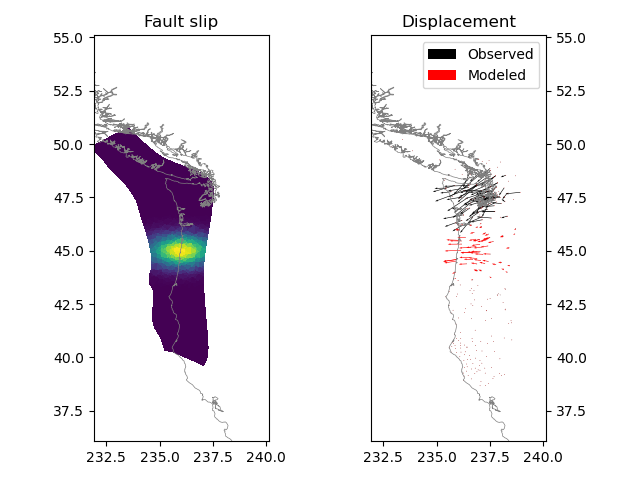

In [10]:
# Radial slip distribution 

# Center coordinates of radial slip distribution
lon_center = 236 
lat_center = 45
# 3 parameters: slip gradient in x, y directions plus rotation angle
slip_shape = np.array([1, .5, 0])
# The selected parameters 
s = radgauss(lon_center, lat_center, 1, mesh["centroids"][:, 0], mesh["centroids"][:, 1], slip_shape)

# Create full slip distribution, adding radial slip as dip-slip 
slip = np.vstack((np.zeros_like(s), 10*s, np.zeros_like(s))).T

# Calculate predicted displacement at grid points that arises from fault slip
pred_disp = disp_mat.dot(slip.reshape(3*ntri, 1))

plt.close('all')
# Visualize the slip and displacement pattern 
fig, ax = plt.subplots(1, 2)
fso = ax[0].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=s)
# fig.colorbar(fso, ax=ax[0], orientation='horizontal')
ax[0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0].set(xlim=(lonmin, lonmax), ylim=(latmin, latmax), aspect='equal')
ax[0].title.set_text("Fault slip")

# Observed displacements 
ax[1].quiver(gnss.lon, gnss.lat, gnss.east_disp, gnss.north_disp, color='k', scale=50, label="Observed")
# Predicted displacements 
ax[1].quiver(gnss.lon, gnss.lat, pred_disp[0::3], pred_disp[1::3], color='r', scale=50, label="Modeled")

# Add coastline
ax[1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1].set(xlim=(lonmin, lonmax), ylim=(latmin, latmax), aspect='equal')
ax[1].legend()
ax[1].yaxis.tick_right()
ax[1].title.set_text("Displacement")

fig.tight_layout()
plt.show()

## Inversion of displacement data for slip

### Calculate smoothing matrix for fault

In [11]:
# We first need to determine the neighbors of each element, defined as those that share a side 
# From https://github.com/brendanjmeade/celeri/blob/main/celeri/spatial.py

def get_shared_sides(vertices):
    """Determine the indices of the triangular elements sharing
    one side with a particular element.
    Inputs:
    vertices: n x 3 array containing the 3 vertex indices of the n elements,
        assumes that values increase monotonically from 1:n.

    Outputs:
    share: n x 3 array containing the indices of the m elements sharing a
        side with each of the n elements.  "-1" values in the array
        indicate elements with fewer than m neighbors (i.e., on
        the edge of the geometry).

    In general, elements will have 1 (mesh corners), 2 (mesh edges), or 3
    (mesh interiors) neighbors, but in the case of branching faults that
    have been adjusted with mergepatches, it's for edges and corners to
    also up to 3 neighbors.
    """
    # Make side arrays containing vertex indices of sides
    side_1 = np.sort(np.vstack((vertices[:, 0], vertices[:, 1])).T, 1)
    side_2 = np.sort(np.vstack((vertices[:, 1], vertices[:, 2])).T, 1)
    side_3 = np.sort(np.vstack((vertices[:, 0], vertices[:, 2])).T, 1)
    sides_all = np.vstack((side_1, side_2, side_3))

    # Find the unique sides - each side can part of at most 2 elements
    _, first_occurence_idx = np.unique(sides_all, return_index=True, axis=0)
    _, last_occurence_idx = np.unique(np.flipud(sides_all), return_index=True, axis=0)
    last_occurence_idx = sides_all.shape[0] - last_occurence_idx - 1

    # Shared sides are those whose first and last indices are not equal
    shared = np.where((last_occurence_idx - first_occurence_idx) != 0)[0]

    # These are the indices of the shared sides
    sside1 = first_occurence_idx[shared]  
    sside2 = last_occurence_idx[shared]

    el1, sh1 = np.unravel_index(
        sside1, vertices.shape, order="F"
    )  # "F" is for fortran ordering.  
    el2, sh2 = np.unravel_index(sside2, vertices.shape, order="F")
    share = -1 * np.ones((vertices.shape[0], 3))
    for i in range(el1.size):
        share[el1[i], sh1[i]] = el2[i]
        share[el2[i], sh2[i]] = el1[i]
    share = share.astype(int)
    return share

# Using the indices of the shared sides, we can construct the smoothing matrix
# From https://github.com/brendanjmeade/celeri/blob/main/celeri/spatial.py

def get_tri_smoothing_matrix_simple(share, n_dim):
    """Produces a smoothing matrix based without scale-dependent
    weighting.

    Inputs:
    share: n x 3 array of indices of the up to 3 elements sharing a side with each of the n elements
    n_dim: Number of dimensions (slip components) for each element 

    Outputs:
    smoothing matrix: n_dim * n x n_dim * n smoothing matrix
    """
    # Allocate space for contructing smoothing matrix
    # For large problems, this can be made as a sparse matrix 
    n_shared_tri = share.shape[0]
    smoothing_matrix = np.zeros((n_dim * n_shared_tri, n_dim * n_shared_tri))

    for j in range(n_dim):
        for i in range(n_shared_tri):
            smoothing_matrix[n_dim * i + j, n_dim * i + j] = 3
            if share[i, j] != -1:
                k = n_dim * i + np.arange(n_dim)
                m = n_dim * share[i, j] + np.arange(n_dim)
                smoothing_matrix[k, m] = -1
    return smoothing_matrix


### Assemble matrices, weighting matrix, and data vector

In [68]:
# Call functions to create smoothing matrix
share = get_shared_sides(mesh["verts"])
smoothing_mat = get_tri_smoothing_matrix_simple(share, n_dim=2)

# Assemble matrices

# From the matrix of partial derivatives, 
# Delete ROWS corresponding to vertical displacement
disp_mat_no_vert = np.delete(disp_mat, np.arange(2, 3*nsta, 3), 0)
# Delete COLUMNS corresponding to tensile slip 
disp_mat_final = np.delete(disp_mat_no_vert, np.arange(2, 3*ntri, 3), 1)

assembled_mat = np.vstack([disp_mat_final, smoothing_mat])

# List of smoothing weights to test
smoothing_coefficients = [1e-2, 1e0, 1e2]

# Select a smoothing weight and apply to meshes
smoothing_coefficient = smoothing_coefficients[1]

# Assemble weights: 

# Weights on GNSS displacements are 1/sigma^2
data_uncertainties = np.array([gnss.east_sig, gnss.north_sig]).T.reshape((2*nsta, -1)).copy()
data_weights = 1./data_uncertainties**2

# Weights on pseudodata controlling regularization are applied to all slip rate rows
smoothing_weights = smoothing_coefficient*np.ones((len(smoothing_mat), 1))

# Complete weighting vector
all_weights = np.vstack([data_weights, smoothing_weights])

# Assemble data:

# Displacement vector
disp_vector = np.array([gnss.east_disp, gnss.north_disp]).T.reshape((2*nsta, -1)).copy()

# Psuedodata vector
zero_vector = np.zeros_like(smoothing_weights)

# Complete data vector
all_data = np.vstack([disp_vector, zero_vector])

### Carry out inversion 

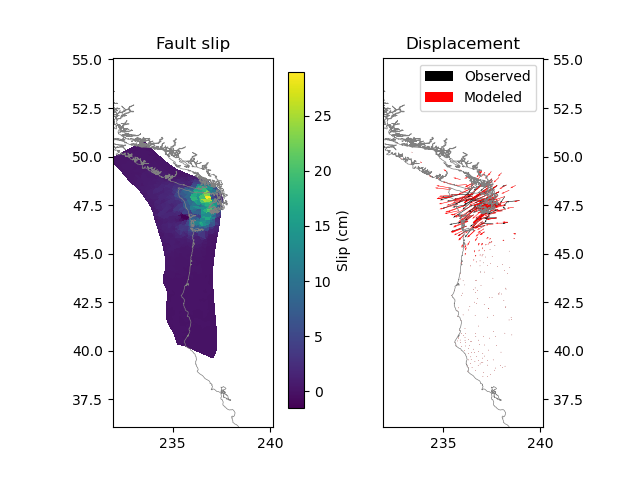

In [69]:
# Calculate model covariance
cov = np.linalg.inv(assembled_mat.T * all_weights.T @ assembled_mat) 

# Estimate slip using pre-calculated covariance
est_slip = cov @ assembled_mat.T *all_weights.T @ all_data 
# Predict displacement at stations
pred_sse_disp = disp_mat_final.dot(est_slip)

# Visualize the slip and displacement pattern 
fig, ax = plt.subplots(1, 2)
fso = ax[0].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=est_slip[1::2, 0])
ax[0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0].set(xlim=(lonmin, lonmax), ylim=(latmin, latmax), aspect='equal')
ax[0].title.set_text("Fault slip")

# Observed displacements 
ax[1].quiver(gnss.lon, gnss.lat, gnss.east_disp, gnss.north_disp, color='k', scale=50, label="Observed")
# Predicted displacements 
ax[1].quiver(gnss.lon, gnss.lat, pred_sse_disp[0::2], pred_sse_disp[1::2], color='r', scale=50, label="Modeled")

# Add coastline
ax[1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1].set(xlim=(lonmin, lonmax), ylim=(latmin, latmax), aspect='equal')
ax[1].legend()
ax[1].yaxis.tick_right()
ax[1].title.set_text("Displacement")

# fig.subplots_adjust(=0.8)
cbar_ax = fig.add_axes([0.45, 0.15, 0.025, 0.7])
fig.colorbar(fso, cax=cbar_ax, label="Slip (cm)")
plt.show()

In [37]:
print(len(est_slip[1::2]))

1430
